# Estimating Areas using Monte Carlo Simulation

### Estimating Pi (Using $f(x) = \sqrt{1-x^2}, 0 \le x \le 1$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math


In [2]:
# Estimation using Method 1 : Average Value Method

N = 1000
num_trials = 10
pi_ests1 = []
for _ in range(num_trials):
    samples = np.random.rand(N)
    y = np.sqrt(1 - samples**2)
    pi_ests1.append(4 * np.mean(y))
    
piMean = np.mean(pi_ests1)
piStd = np.std(pi_ests1, ddof=1)
CI99 = 2.5 * (piStd / np.sqrt(num_trials))
print(f"Estimated value of pi = {piMean:.6f} ± {CI99:.6f}, with 99% confidence")


Estimated value of pi = 3.144831 ± 0.021827, with 99% confidence


In [3]:
# Estimation using Method 2 : Area Method

pi_ests2 = []
for _ in range(num_trials):
    x = np.random.rand(N)
    y = np.random.rand(N)
    under_f = (y <= np.sqrt(1 - x**2))
    pi_ests2.append(4 * np.mean(under_f))

piMean = np.mean(pi_ests2)
piStd = np.std(pi_ests2, ddof=1)
CI99 = 2.5 * (piStd / np.sqrt(num_trials))
print(f"Estimated value of pi = {piMean:.6f} ± {CI99:.6f}, with 99% confidence")


Estimated value of pi = 3.149200 ± 0.045996, with 99% confidence


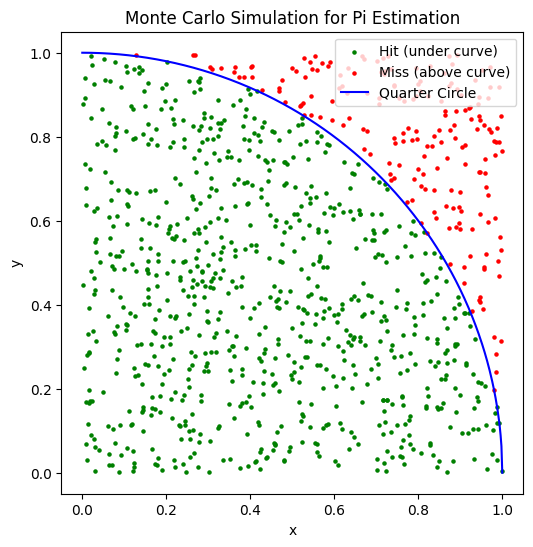

In [4]:
# Plotting Method 2

plt.figure(figsize=(6,6))
plt.scatter(x[under_f], y[under_f], color='green', s=5, label='Hit (under curve)')
plt.scatter(x[~under_f], y[~under_f], color='red', s=5, label='Miss (above curve)')

xcurve = np.linspace(0,1,500)
ycurve = np.sqrt(1 - xcurve**2)
plt.plot(xcurve, ycurve, 'b', label='Quarter Circle')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Monte Carlo Simulation for Pi Estimation')
plt.legend()
plt.axis('square')
plt.show()


### Estimating area under $y = \sin(20\pi x) + 1, 0 \le x \le 1$

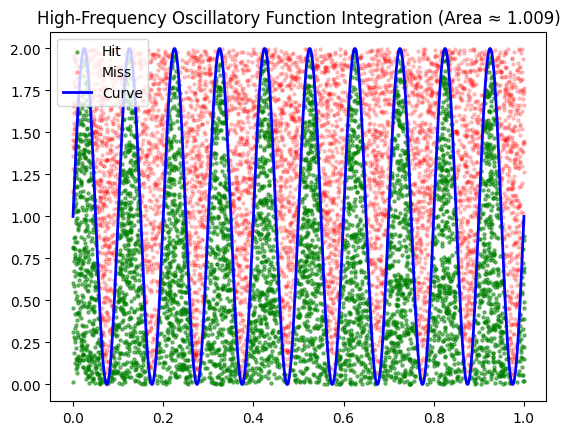

In [5]:
N = 10000

x = np.random.rand(N)
y = np.random.uniform(0,2,N)
curve = lambda x: np.sin(20 * np.pi * x) + 1

hits = y <= curve(x)
misses = ~hits

area_est = (np.sum(hits) / N) * 2

plt.scatter(x[hits], y[hits], color='green', s=5, alpha=0.5, label='Hit')
plt.scatter(x[misses], y[misses], color='red', s=5, alpha=0.2, label='Miss')
xs = np.linspace(0,1,1000)
plt.plot(xs, curve(xs), 'b', lw=2, label='Curve')
plt.title(f"High-Frequency Oscillatory Function Integration (Area ≈ {area_est:.3f})")
plt.legend()
plt.show()
